In [1]:
import numpy as np

# Constants
g, l, b, m = 9.81, 5, 0.1, 2
A, B = -g / l, -b / m

# Define the system dynamics numerically
def f(x1, x2):
    return np.array([x2, A * np.sin(x1) - B * x2])

def G(x1, x2):
    return np.array([[0, 0], [0, 1]])

def Q(x1, x2):
    return np.array([[1, 0], [0, 1]])

def R(x1, x2):
    return np.array([[1, 0], [0, 1]])

#x1 = np.linspace(-5, 5, 100)
#x2 = np.linspace(-5, 5, 100)



# Safe divide function
def safe_divide(a, b, default=1):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(np.abs(b) > 1e-9, a / b, default)
    return result

# Compute V, V_dot, and related terms numerically
def compute_v_and_v_dot(V_function, x1_vals, x2_vals):
    
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    # Evaluate system dynamics
    f_vector = f(X1, X2)
    G_matrix = G(X1, X2)
    Q_matrix = Q(X1, X2)
    R_matrix = R(X1, X2)



    # Evaluate V
    V_vals = V_function(X1, X2)  # Numerical potential function
    print(V_vals.shape)
    print(V_vals)

    # Compute numerical gradients
    V_grad_x1 = np.gradient(V_vals, x1_vals, axis=1)  # Gradient w.r.t x1
    V_grad_x2 = np.gradient(V_vals, x2_vals, axis=0)  # Gradient w.r.t x2
    V_grad = np.stack([V_grad_x1, V_grad_x2], axis=-1)  # Combine gradients into vector field
 

    # Compute control terms
    b_T = np.einsum('ijk,kl->ijl', V_grad, G_matrix)
    a = np.einsum('ijk,kij->ij', V_grad, f_vector)

    # Compute norms
    x_stack = np.dstack([X1, X2])  # Combine X1 and X2 into a 3D array
    x_norm_squared = np.einsum('ijk,kl,ijl->ij', x_stack, Q_matrix, x_stack)  # Quadratic form
    b_norm_squared = np.einsum('ijk,kl,ijl->ij', b_T, np.linalg.inv(R_matrix), b_T)

    lambda_x_vals = safe_divide(
        np.sqrt(a ** 2 + x_norm_squared * b_norm_squared) + a,
        b_norm_squared,
        default=0
    )


    u_vals = -np.einsum('kl,ijk,ij->ijk', np.linalg.inv(R_matrix), b_T, lambda_x_vals)
    V_dot_vals = np.einsum('ijk,ijk->ij', V_grad, f_vector.transpose(1, 2, 0)) + \
            np.einsum('ijk,ijk->ij', V_grad, np.einsum('kl,ijk->ijk', G_matrix, u_vals))
    u_mag = np.einsum('ijk,kl,ijk->ij', u_vals, R_matrix, u_vals)

    # Perform the dot product
    V_grad_transformed  = u_mag

    return V_vals, V_dot_vals, lambda_x_vals, u_vals[..., 1], u_mag

In [6]:
# Define the numerical potential function
def V_function(x1, x2):
    #return 0.5*x2**2 - np.cos(x1) + 1  
    #return x2/x1 + np.cos(x1)
    #return x2**2
    #return np.sin(x1*x2) + x2*x1
    #return np.cos(x2) + x1/x2
    #return (x1*x2*(x1 + x2) - (np.sin(x1) - x2)*(x1 + x2**2))*(np.cos(x2) + np.sin(x2)*x1 + x2*(-x1 + 3*x2))/(x1*x2**2)
    #return np.cos(x2) + x1*(5*x1 + x2 - np.cos(x1 - x2))
    #return np.sin(x1*x2) + np.sin(np.cos(x1) + 2*x1) - np.sin(np.sin(x1) + 2*x2) + np.sin(np.cos(2*x2)) + np.cos(np.cos(x1)*x1**2) + np.cos(np.cos(np.cos(x2)))
    #return (-np.cos(x1) - 2 * np.sin(x2) * x1 - 2 * x1) * (np.sin(x1) - np.sin(x2) + x1 + x2 - np.sin(x1**2) - 1) * np.sin(np.cos(x1**2)))
    #return np.cos(x2) +    2 * x1 * (np.cos(x1) + x1) +    x2 +    (x1 + x2) * (-np.cos(x1) + x1 + x2)
    #return (-np.cos(x2) + np.sin(x1) + x1 * x2 + 2 * x1 + x2**2 + 2 * x2 + (x1 - x2)**2 * (-np.sin(x1) + x1 - x2) - np.sin(np.sin(x2)) - np.sin(x1 + x2))
    #return -np.sin(np.cos(x1) + np.cos(x2) * x1**2 + np.sin(x1) * (np.cos(x1) + x1 + x2) + np.sin(x2) * (-x1 + x2 + np.cos(np.sin(x2))) * np.cos(x1 - x2) - np.sin(x2))
    #return np.cos(x2) + 2 * x1**2 + 2 * x1 * x2 + 2 * x2**2 - x2
    #return np.cos(x1) + 4 * x1**2 + 2 * x1 * x2 + x2
    ##return 85.5250*x1**2 + 2*14.1518*x1*x2 + 2.4269*x2**2
    #return (np.sin(x2) + x1)*(np.cos(x1)*np.sin(x1) + np.sin(x2) + x1 + x2)
    #return np.sin(x1)*(np.cos(x1)*(np.cos(x2)*(np.sin(x1) + x1) + x1) + x1) + x2**2
    ##return (x2 * (x2 + (np.cos(x2) * np.sin(x2) + x2) * (np.cos(x2) * (np.cos(x2) * (np.cos(x2) + 1) + 1) + 1)))
    ##return x2*(-x1 + 3*x2)
    return 2*x1**2 + x1*(-x1**2*x2 + x1) + (2*x1 + x2)*(4*x1 + 2*x2)


# Define the numerical grid
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3, 3, 100)

# Compute values
V_vals, V_dot_vals, lambda_x_vals, u_vals, u_mag  = compute_v_and_v_dot(V_function, x1_vals, x2_vals)
#, V_dot, lambda_x, u_value, u_mag = compute_v_and_v_dot(V_function, x1_vals, x2_vals)

# Output results
#print("V_value shape:", V_value.shape)
'''
print("V_dot shape:", V_dot.shape)
print("lambda_x shape:", lambda_x.shape)
print("u_value shape:", u_value.shape)
print("u_mag shape:", u_mag.shape)
'''

(100, 100)
[[108.         107.39644378 106.67935554 ... 111.64387678 118.6843643
  126.        ]
 [107.46189164 106.79053664 106.00957568 ... 110.87380357 117.85041837
  125.09825528]
 [106.93847567 106.19932188 105.3544882  ... 110.11842273 117.03116481
  124.21120294]
 ...
 [124.21120294 117.03116481 110.11842273 ... 105.3544882  106.19932188
  106.93847567]
 [125.09825528 117.85041837 110.87380357 ... 106.00957568 106.79053664
  107.46189164]
 [126.         118.6843643  111.64387678 ... 106.67935554 107.39644378
  108.        ]]


'\nprint("V_dot shape:", V_dot.shape)\nprint("lambda_x shape:", lambda_x.shape)\nprint("u_value shape:", u_value.shape)\nprint("u_mag shape:", u_mag.shape)\n'

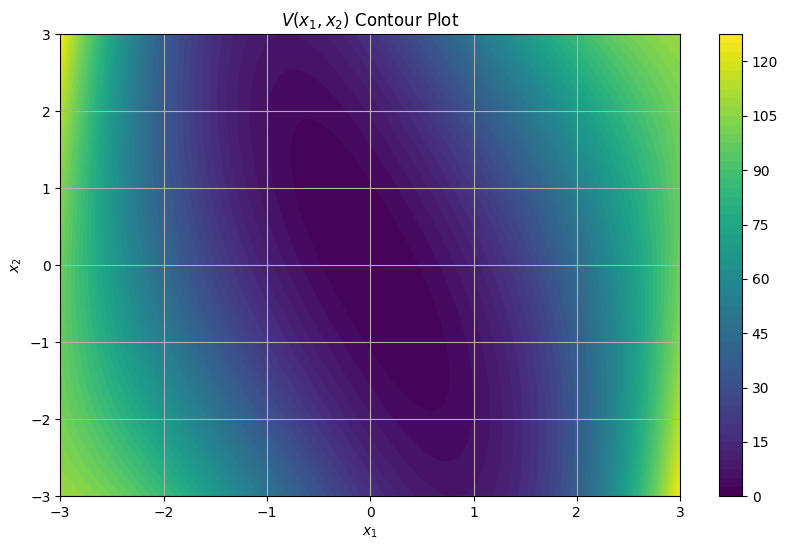

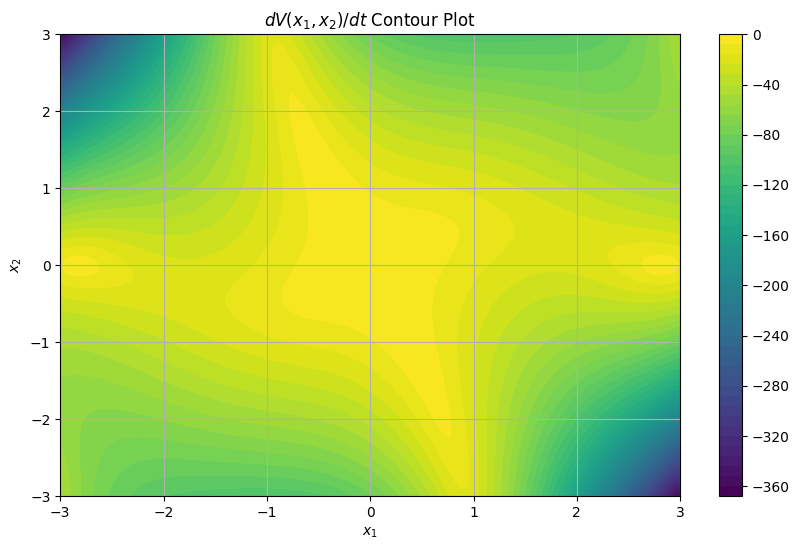

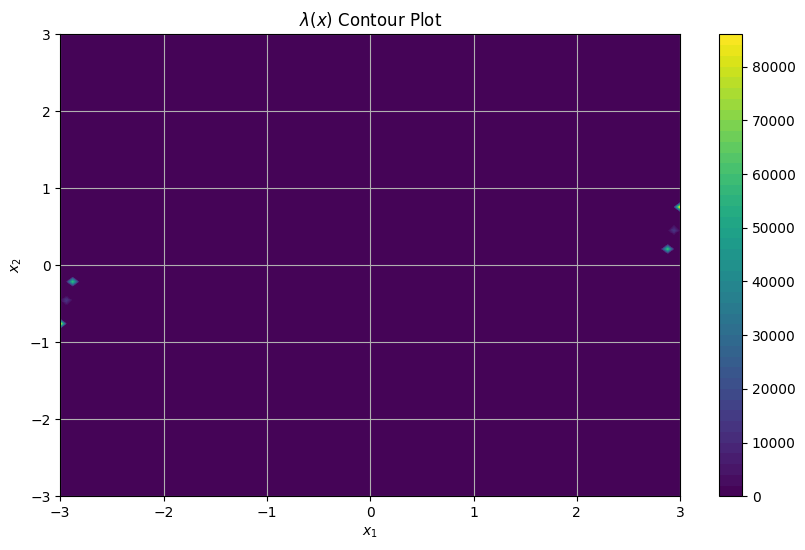

mean value of lambda:
33.23293255519576


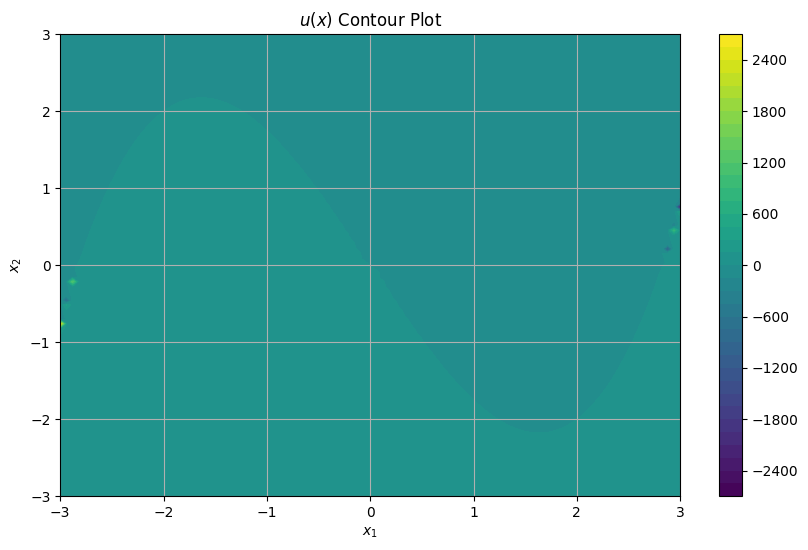

In [7]:
import matplotlib.pyplot as plt

X1 = x1_vals
X2 = x2_vals

#print(V_value.shape)

# Plot V(x1, x2)
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x_1, x_2)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of V_x1
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_dot_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$d V(x_1, x_2) / dt$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of lambda_x
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, lambda_x_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\lambda(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

print('mean value of lambda:')
print(np.mean(lambda_x_vals))

#u_comp = u_vals[..., 1:2]
#u_comp = u_comp.reshape(50, 50)  # Reshapes
# Plot the contour of lambda_x
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()